#Importar librerias y preparacion de los datos
---

In [4]:
import pandas as pd
import numpy as np
import pyarrow.parquet
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import warnings

In [5]:
#Se especifica la ruta
file_application = "datos_examen/application_.parquet"
file_bureau = "datos_examen/bureau.parquet"
file_bureau_balance = "datos_examen/bureau_balance.parquet"
file_previous_application = "datos_examen/previous_application.parquet"

# Se cargan los DataFrames
df_application = pd.read_parquet(file_application)
df_bureau = pd.read_parquet(file_bureau)
df_bureau_balance = pd.read_parquet(file_bureau_balance)
df_previous_application = pd.read_parquet(file_previous_application)

print("¡Archivos cargados con éxito!")
print(f"application_ rows: {len(df_application)}")
print(f"bureau rows: {len(df_bureau)}")
print(f"bureau_balance rows: {len(df_bureau_balance)}")
print(f"previous_application rows: {len(df_previous_application)}")

¡Archivos cargados con éxito!
application_ rows: 307511
bureau rows: 1716428
bureau_balance rows: 27299925
previous_application rows: 1670214


In [6]:
#Se une el bureau_balance al bureau
# Agregación de bureau_balance: Conteo de STATUS (categórica)
df_bureau_balance_status = pd.get_dummies(df_bureau_balance, columns=['STATUS'], prefix='STATUS_BB')
bureau_balance_counts = df_bureau_balance_status.groupby('SK_ID_BUREAU').sum()

# Agregación de meses (numérica)
bureau_balance_counts['MONTHS_COUNT'] = df_bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].count()

# Unión de bureau_balance al df_bureau
df_bureau_merged = df_bureau.merge(
    bureau_balance_counts,
    on='SK_ID_BUREAU',
    how='left' # Mantenemos todos los créditos de 'bureau'
)

In [7]:
#Union del "bureau unido" al application_
# --- Resumen de Variables Numéricas de Bureau ---
numerical_cols = df_bureau_merged.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'SK_ID_CURR' and col != 'SK_ID_BUREAU']

# Definir funciones de agregación
agg_funcs = ['mean', 'sum', 'min', 'max', 'count']

# Agrupar y agregar
df_bureau_num_agg = df_bureau_merged.groupby('SK_ID_CURR').agg({
    col: agg_funcs for col in numerical_cols
})

# Renombrar columnas
df_bureau_num_agg.columns = [f'BUREAU_{col[0]}_{col[1].upper()}' for col in df_bureau_num_agg.columns]
df_bureau_num_agg = df_bureau_num_agg.reset_index()

# --- Resumen de Variables Categóricas de Bureau ---
categorical_cols = df_bureau_merged.select_dtypes(include='object').columns.tolist()

df_bureau_cat_agg = pd.DataFrame({'SK_ID_CURR': df_bureau_merged['SK_ID_CURR'].unique()})

for col in categorical_cols:
    # Aplicar One-Hot Encoding
    dummies = pd.get_dummies(df_bureau_merged[['SK_ID_CURR', col]], columns=[col], prefix=f'BUREAU_CAT_{col}')
    
    # Agrupar y sumar (para contar las ocurrencias por cliente)
    dummies_agg = dummies.groupby('SK_ID_CURR').sum().reset_index()
    
    # Unir al DataFrame de categorías
    df_bureau_cat_agg = df_bureau_cat_agg.merge(dummies_agg, on='SK_ID_CURR', how='left')
    
# --- Unión de las Agregaciones ---
df_bureau_final = df_bureau_num_agg.merge(
    df_bureau_cat_agg,
    on='SK_ID_CURR',
    how='outer'
)

# --- Unión Final al DataFrame Principal (application_) ---
df_application_merged = df_application.merge(
    df_bureau_final,
    on='SK_ID_CURR',
    how='left'
)

In [8]:
#Union del application_ al previous_application
# --- Separación de Variables Numéricas y Categóricas ---
df_prev_agg = df_previous_application.copy()
df_prev_agg = df_prev_agg.drop(columns=['SK_ID_PREV']) # Eliminar ID de solicitud previa

# --- Agregación de Variables Numéricas (df_previous_application) ---
numerical_cols = df_prev_agg.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'SK_ID_CURR']

agg_funcs = ['mean', 'sum', 'min', 'max', 'count']
agg_dict_num = {col: agg_funcs for col in numerical_cols}

df_prev_num_agg = df_prev_agg.groupby('SK_ID_CURR').agg(agg_dict_num)

# Renombrar columnas con prefijo PREV_
df_prev_num_agg.columns = [f'PREV_{col[0]}_{col[1].upper()}' for col in df_prev_num_agg.columns]
df_prev_num_agg = df_prev_num_agg.reset_index()

# --- Agregación de Variables Categóricas (df_previous_application) ---
categorical_cols = df_prev_agg.select_dtypes(include='object').columns.tolist()

df_prev_cat_agg = pd.DataFrame({'SK_ID_CURR': df_prev_agg['SK_ID_CURR'].unique()})

for col in categorical_cols:
    # Aplicar One-Hot Encoding
    dummies = pd.get_dummies(df_prev_agg[['SK_ID_CURR', col]], columns=[col], prefix=f'PREV_CAT_{col}')
    
    # Agrupar y sumar
    dummies_agg = dummies.groupby('SK_ID_CURR').sum().reset_index()
    
    # Unir
    df_prev_cat_agg = df_prev_cat_agg.merge(dummies_agg, on='SK_ID_CURR', how='left')


# --- Definición de df_prev_final ---
# Unión Final de Agregaciones Numéricas + Categóricas
df_prev_final = df_prev_num_agg.merge(
    df_prev_cat_agg,
    on='SK_ID_CURR',
    how='outer'
)

# --- Unión al DataFrame principal (application_merged del paso 2) ---
df_final_merged = df_application_merged.merge(
    df_prev_final,
    on='SK_ID_CURR',
    how='left'
)

# Guardar el resultado final
df_final_merged.to_parquet("df_final_credit_scoring_merged.parquet", index=False)

#Modelado
---

#PCA
---

#PCA Preparacion

In [9]:
# 1. Cargar el DataFrame final
df_final = pd.read_parquet("df_final_credit_scoring_merged.parquet")

# 2. Excluir IDs y TARGET
df_pca = df_final.drop(columns=['SK_ID_CURR', 'TARGET'], errors='ignore')

# 3. Seleccionar solo variables numéricas (ya que la mayoría de categóricas fueron convertidas en el merge)
df_pca_numeric = df_pca.select_dtypes(include=np.number)
print(f"DataFrame para PCA antes de imputación: {df_pca_numeric.shape}")

DataFrame para PCA antes de imputación: (307511, 475)


In [10]:
# Reemplazar NaN con la media
imputer = SimpleImputer(strategy='mean')

# Ajustar y transformar (fit_transform) el DataFrame
df_pca_imputed = imputer.fit_transform(df_pca_numeric)

# Volver a convertir a DataFrame para mantener los nombres de columna
df_pca_imputed = pd.DataFrame(df_pca_imputed, columns=df_pca_numeric.columns)
print("Valores faltantes imputados con la media.")

Valores faltantes imputados con la media.


In [11]:
# Escalar los datos imputados
scaler = StandardScaler()
df_pca_scaled = scaler.fit_transform(df_pca_imputed)

# Volver a convertir a DataFrame
df_pca_scaled = pd.DataFrame(df_pca_scaled, columns=df_pca_imputed.columns)
print("Datos escalados con StandardScaler (Media=0, Desv. Est.=1).")
print(f"DataFrame listo para PCA: {df_pca_scaled.shape}")

Datos escalados con StandardScaler (Media=0, Desv. Est.=1).
DataFrame listo para PCA: (307511, 475)


#PCA aplicacion

In [12]:
# Aplicar PCA sin límite de componentes para capturar la varianza total
pca = PCA()
pca.fit(df_pca_scaled)

# Calcular la varianza acumulada
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Encontrar el número de componentes que explican el 90% de la varianza
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

# Transformar los datos al número óptimo de componentes
pca_90 = PCA(n_components=n_components_90)
df_pca_final = pca_90.fit_transform(df_pca_scaled)

# Volver a convertir a DataFrame con nombres de componentes
pca_cols = [f'PC_{i+1}' for i in range(n_components_90)]
df_pca_final = pd.DataFrame(df_pca_final, columns=pca_cols)

print("\n--- Resultados del Análisis de PCA ---")
print(f"Se necesitan {n_components_90} componentes (de las {df_pca_numeric.shape[1]} iniciales) para explicar el 90% de la varianza total de los datos.")
print(f"DataFrame reducido (df_pca_final) tiene: {df_pca_final.shape[1]} columnas.")


--- Resultados del Análisis de PCA ---
Se necesitan 192 componentes (de las 475 iniciales) para explicar el 90% de la varianza total de los datos.
DataFrame reducido (df_pca_final) tiene: 192 columnas.


PC_1: 0.0981
PC_2: 0.0471
PC_3: 0.0377
PC_4: 0.0282
PC_5: 0.0212
PC_6: 0.0202
PC_7: 0.0185
PC_8: 0.0157
PC_9: 0.0148
PC_10: 0.0125


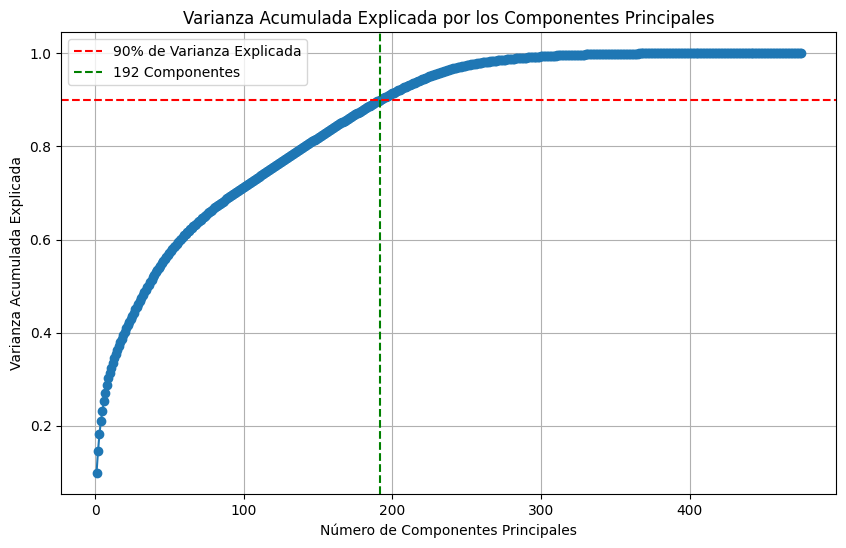

In [14]:
# Mostrar la varianza explicada por los primeros 10 PCs
variance_explained = pca.explained_variance_ratio_[:10]
for i, var in enumerate(variance_explained):
    print(f"PC_{i+1}: {var:.4f}")

# Graficar la Varianza Acumulada
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% de Varianza Explicada')
plt.axvline(x=n_components_90, color='g', linestyle='--', label=f'{n_components_90} Componentes')
plt.title('Varianza Acumulada Explicada por los Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.legend()
plt.grid(True)
plt.show()

#K-means
---

#K-means Metodo del codo(Elbow method)

Calculando la Inercia para el Método del Codo...
K=2 calculado.
K=3 calculado.
K=4 calculado.
K=5 calculado.
K=6 calculado.
K=7 calculado.
K=8 calculado.
K=9 calculado.
K=10 calculado.


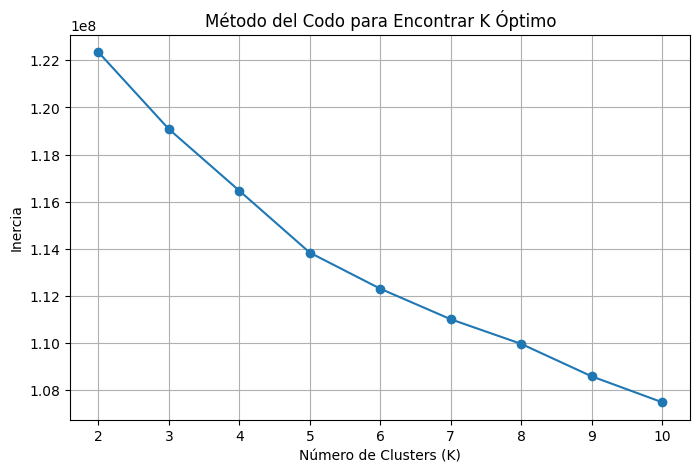

In [10]:
warnings.filterwarnings('ignore') # Ignorar advertencias de convergencia

# X será el DataFrame reducido por PCA
X = df_pca_final 

inertia = []
K_range = range(2, 11) # Probaremos de K=2 a K=10 clusters

print("Calculando la Inercia para el Método del Codo...")

for k in K_range:
    # Inicializar K-Means con un número fijo de repeticiones y semilla (random_state)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    print(f"K={k} calculado.")

# Visualización del Método del Codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Método del Codo para Encontrar K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

In [11]:
# Suponiendo que elegimos K=5
K_optimo = 5

# Aplicar K-Means con el número óptimo de clusters
final_kmeans = KMeans(n_clusters=K_optimo, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X)

# Asignar la etiqueta del cluster al DataFrame original (df_final)
df_final['KMEANS_CLUSTER'] = cluster_labels

print(f"\n✅ K-Means aplicado con K={K_optimo}.")
print("Etiquetas de clusters añadidas al DataFrame final.")
print(f"Distribución de Clusters:\n{df_final['KMEANS_CLUSTER'].value_counts().sort_index()}")


✅ K-Means aplicado con K=5.
Etiquetas de clusters añadidas al DataFrame final.
Distribución de Clusters:
KMEANS_CLUSTER
0     23796
1    112996
2    131191
3     13891
4     25637
Name: count, dtype: int64


In [12]:
# Calcular la tasa de incumplimiento (mora) para cada cluster
cluster_analysis = df_final.groupby('KMEANS_CLUSTER')['TARGET'].agg(['count', 'mean'])
cluster_analysis.columns = ['Total Clientes', 'Tasa de Incumplimiento Promedio']

print("\n--- Análisis de Riesgo por Cluster ---")
print(cluster_analysis.to_markdown())

# Análisis de Perfil
# Comparar el perfil demográfico o financiero promedio de cada cluster
cluster_profile = df_final.groupby('KMEANS_CLUSTER')['AMT_INCOME_TOTAL'].mean().reset_index()
cluster_profile.columns = ['KMEANS_CLUSTER', 'Ingreso Promedio']
print("\n--- Ingreso Promedio por Cluster ---")
print(cluster_profile.to_markdown())


--- Análisis de Riesgo por Cluster ---
|   KMEANS_CLUSTER |   Total Clientes |   Tasa de Incumplimiento Promedio |
|-----------------:|-----------------:|----------------------------------:|
|                0 |            23796 |                         0.077534  |
|                1 |           112996 |                         0.0765425 |
|                2 |           131191 |                         0.0855242 |
|                3 |            13891 |                         0.0512562 |
|                4 |            25637 |                         0.0935757 |

--- Ingreso Promedio por Cluster ---
|    |   KMEANS_CLUSTER |   Ingreso Promedio |
|---:|-----------------:|-------------------:|
|  0 |                0 |             196518 |
|  1 |                1 |             170232 |
|  2 |                2 |             154516 |
|  3 |                3 |             210851 |
|  4 |                4 |             187043 |


#K-means metodo de silueta

Tomando una muestra del 10.0% para el cálculo de Silueta...
Tamaño de la muestra para Silueta: 30751 filas.
Calculando Coeficiente de Silueta en la MUESTRA (K=2 a K=10)...
K=2 | Coeficiente de Silueta: 0.1850
K=3 | Coeficiente de Silueta: 0.1595
K=4 | Coeficiente de Silueta: 0.1578
K=5 | Coeficiente de Silueta: 0.1545
K=6 | Coeficiente de Silueta: 0.0388
K=7 | Coeficiente de Silueta: 0.0728
K=8 | Coeficiente de Silueta: 0.0313
K=9 | Coeficiente de Silueta: 0.0209
K=10 | Coeficiente de Silueta: 0.0244


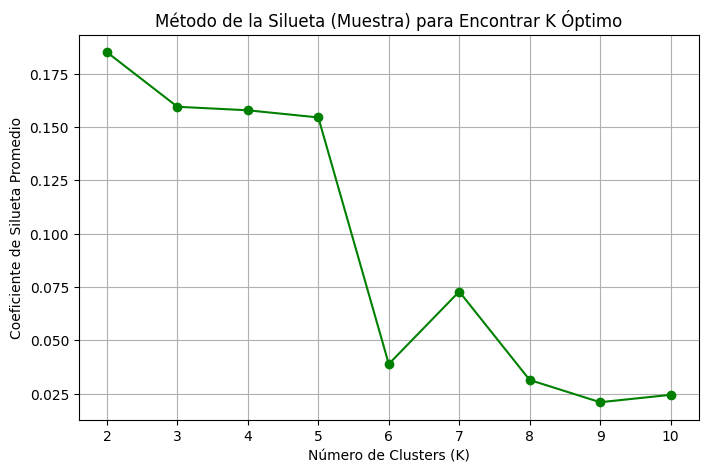


--- Resultado de la Validación ---
El K que maximiza el Coeficiente de Silueta es K=2.


In [13]:
# X es el DataFrame reducido por PCA (df_pca_final)
# Asumiendo que X está definido y contiene los datos escalados y reducidos (~307,000 filas)

# MUESTREO DEL DATASET
SAMPLE_RATE = 0.10 # 10% de la población (~30,751 clientes)
print(f"Tomando una muestra del {SAMPLE_RATE*100}% para el cálculo de Silueta...")

# Crear una muestra aleatoria del 10% de los datos para acelerar el cálculo
# random_state asegura que la muestra sea reproducible
X_sample = pd.DataFrame(X).sample(frac=SAMPLE_RATE, random_state=42).values 
print(f"Tamaño de la muestra para Silueta: {X_sample.shape[0]} filas.")

# MÉTODO DE LA SILUETA EN LA MUESTRA
silhouette_scores = []
K_range = range(2, 11) 

print("Calculando Coeficiente de Silueta en la MUESTRA (K=2 a K=10)...")

for k in K_range:
    # Aplicar K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_sample)
    
    # Calcular la puntuación de silueta
    score = silhouette_score(X_sample, cluster_labels)
    silhouette_scores.append(score)
    print(f"K={k} | Coeficiente de Silueta: {score:.4f}")

# Visualización del Resultado
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.title('Método de la Silueta (Muestra) para Encontrar K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Coeficiente de Silueta Promedio')
plt.grid(True)
plt.show()

# DETERMINACIÓN DEL K ÓPTIMO
# Encontrar el K que produjo el score más alto
best_k_index = np.argmax(silhouette_scores)
K_optimo = K_range[best_k_index]

print(f"\n--- Resultado de la Validación ---")
print(f"El K que maximiza el Coeficiente de Silueta es K={K_optimo}.")

#Dendrograma

Calculando linkage para 1000 muestras...


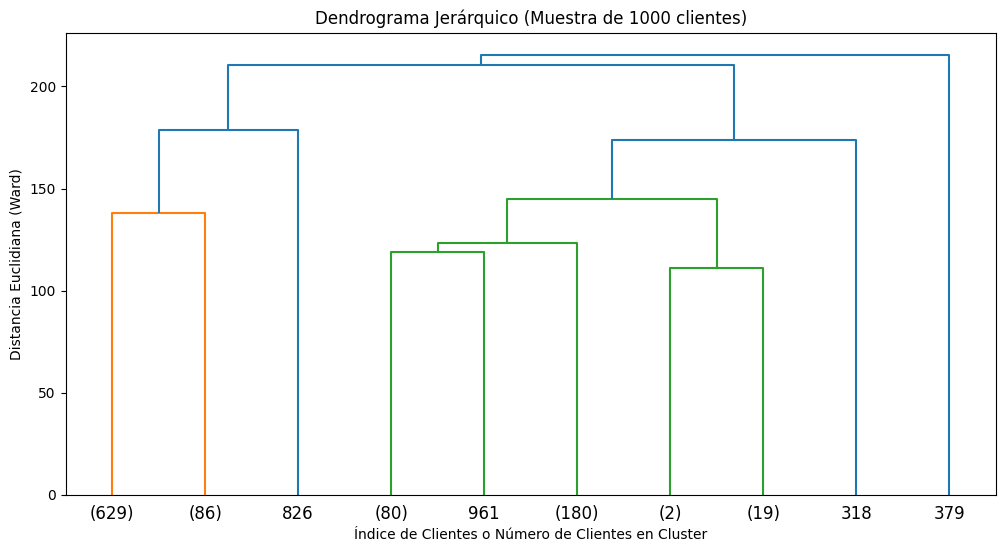

In [19]:
# X es el DataFrame reducido por PCA (df_pca_final)
# Se necesita una muestra MUY pequeña para el dendrograma (ej., 1000 clientes)
SAMPLE_SIZE = 1000
X_dendro_sample = pd.DataFrame(X).sample(n=SAMPLE_SIZE, random_state=42).values 

print(f"Calculando linkage para {SAMPLE_SIZE} muestras...")

# 1. Calcular la matriz de linkage (la forma en que se unen los clusters)
# Método: 'ward' minimiza la varianza dentro de cada cluster.
# Métrica: 'euclidean' (distancia euclidiana).
linked = linkage(X_dendro_sample, method='ward', metric='euclidean')

# 2. Generar el Dendrograma
plt.figure(figsize=(12, 6))

# Dibujar el dendrograma. truncate_mode='lastp' muestra solo los últimos 10 clusters formados.
dendrogram(
    linked,
    orientation='top',
    labels=np.array(range(SAMPLE_SIZE)),
    distance_sort='descending',
    show_leaf_counts=True,
    truncate_mode='lastp',
    p=10 # Mostrar solo 10 clusters principales
)

plt.title('Dendrograma Jerárquico (Muestra de 1000 clientes)')
plt.xlabel('Índice de Clientes o Número de Clientes en Cluster')
plt.ylabel('Distancia Euclidiana (Ward)')
plt.show()

#Isolation Forest
---

In [20]:
# X es el DataFrame reducido por PCA (df_pca_final)
X = df_pca_final 

# Definir la tasa de contaminación (porcentaje de outliers esperados)
# Usaremos 1% (0.01) de contaminación
contamination_rate = 0.01

print(f"Aplicando Isolation Forest con tasa de contaminación: {contamination_rate*100}%...")

# 2. Inicializar y entrenar el modelo Isolation Forest
# n_estimators=100 es el número de árboles
if_model = IsolationForest(
    n_estimators=100, 
    contamination=contamination_rate, 
    random_state=42, 
    n_jobs=-1 # Usar todos los cores disponibles
)

# Entrenar y predecir. La predicción devuelve:
# 1: Observaciones normales (inliers)
# -1: Anomalías (outliers)
outlier_labels = if_model.fit_predict(X)

# Asignar la etiqueta de anomalía al DataFrame original
df_final['ISOLATION_OUTLIER'] = outlier_labels

# 3. Contar y mostrar la distribución de anomalías
outlier_count = df_final['ISOLATION_OUTLIER'].value_counts()

print("✅ Detección de anomalías completada.")
print(f"Total de observaciones: {len(df_final)}")
print(f"Clasificación de Observaciones:\n{outlier_count.to_markdown()}")

Aplicando Isolation Forest con tasa de contaminación: 1.0%...
✅ Detección de anomalías completada.
Total de observaciones: 307511
Clasificación de Observaciones:
|   ISOLATION_OUTLIER |   count |
|--------------------:|--------:|
|                   1 |  304435 |
|                  -1 |    3076 |


In [21]:
# --- EL ANÁLISIS DE ANOMALÍAS ---

# Agrupar por la etiqueta de anomalía y aplicar las funciones de agregación
# Usamos ['count', 'mean'] para obtener el total de clientes y la tasa de incumplimiento promedio
anomaly_analysis = df_final.groupby('ISOLATION_OUTLIER')['TARGET'].agg(['count', 'mean']).reset_index()

# Renombrar las columnas para mayor claridad
anomaly_analysis.columns = ['ISOLATION_OUTLIER', 'Total_Clientes', 'Tasa_Incumplimiento_Promedio']

# Formatear la tasa de incumplimiento
anomaly_analysis['Tasa_Incumplimiento_Promedio'] = (anomaly_analysis['Tasa_Incumplimiento_Promedio'] * 100).round(2).astype(str) + '%'

# Renombrar etiquetas (1 y -1) para el informe
anomaly_analysis['ISOLATION_OUTLIER'] = anomaly_analysis['ISOLATION_OUTLIER'].replace({1: 'Normal', -1: 'Anomalía'})

print("\n--- Análisis de Riesgo: Normal vs. Anomalía ---")
print(anomaly_analysis.to_markdown(index=False))


--- Análisis de Riesgo: Normal vs. Anomalía ---
| ISOLATION_OUTLIER   |   Total_Clientes | Tasa_Incumplimiento_Promedio   |
|:--------------------|-----------------:|:-------------------------------|
| Anomalía            |             3076 | 11.05%                         |
| Normal              |           304435 | 8.04%                          |
